# Cross-Dataset Validation
## Zara Fashion Sales Dataset × Kaggle Customer Shopping Trends
**ITCS 227 – Introduction to Data Science | Mahidol University 2026**

---

### Objective
Compare results from **2 independent datasets** to verify whether patterns found in the main dataset are consistent with an external source, strengthening the reliability of our findings.

| Dataset | Source | Records | Notes |
|---|---|---|---|
| Fashion Sales Dataset | Main project dataset | 2,640 rows | 2018–2025, ZARA |
| Customer Shopping Trends | Kaggle (iamsouravbanerjee) | 3,900 rows | US shoppers |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load & Preprocess Datasets

In [2]:
# Load datasets
df_main   = pd.read_excel('fashion_new_data2.xlsx')
df_kaggle = pd.read_csv('shopping_trends.csv')

# ── Main dataset: map product_name to generic item label ──────────────────
# Data quality note: 'category' column in main dataset does NOT map to product type.
# We use 'product_name' instead and map to equivalent Kaggle item names.
PRODUCT_MAP = {
    'Blouse'         : 'Blouse',
    'Casual Jeans'   : 'Jeans',
    'Chino Shorts'   : 'Shorts',
    'Summer Dress'   : 'Dress',
    'Heels'          : 'Shoes',
    'Pattern Skirt'  : 'Skirt',
    'Biker Jacket'   : 'Jacket',
    'Wool Jacket'    : 'Jacket',
    'Beach Shirt'    : 'Shirt',
    'Business Shirt' : 'Shirt',
}
df_main['item_mapped'] = df_main['product_name'].map(PRODUCT_MAP)

# ── Kaggle dataset: standardise season name ───────────────────────────────
df_kaggle['Season'] = df_kaggle['Season'].replace('Fall', 'Autumn')
df_kaggle['age_group'] = pd.cut(df_kaggle['Age'], bins=[17,24,35,70],
                                 labels=['18-24','25-35','35+'])

SHARED_ITEMS = sorted(set(PRODUCT_MAP.values()))  # 8 items
SEASON_ORDER = ['Spring', 'Summer', 'Autumn', 'Winter']

print(f'Main dataset   : {len(df_main):,} rows')
print(f'Kaggle dataset : {len(df_kaggle):,} rows')
print(f'Shared items   : {SHARED_ITEMS}')

Main dataset   : 2,640 rows
Kaggle dataset : 3,900 rows
Shared items   : ['Blouse', 'Dress', 'Jacket', 'Jeans', 'Shirt', 'Shoes', 'Shorts', 'Skirt']


## 3. Seasonal Demand Comparison

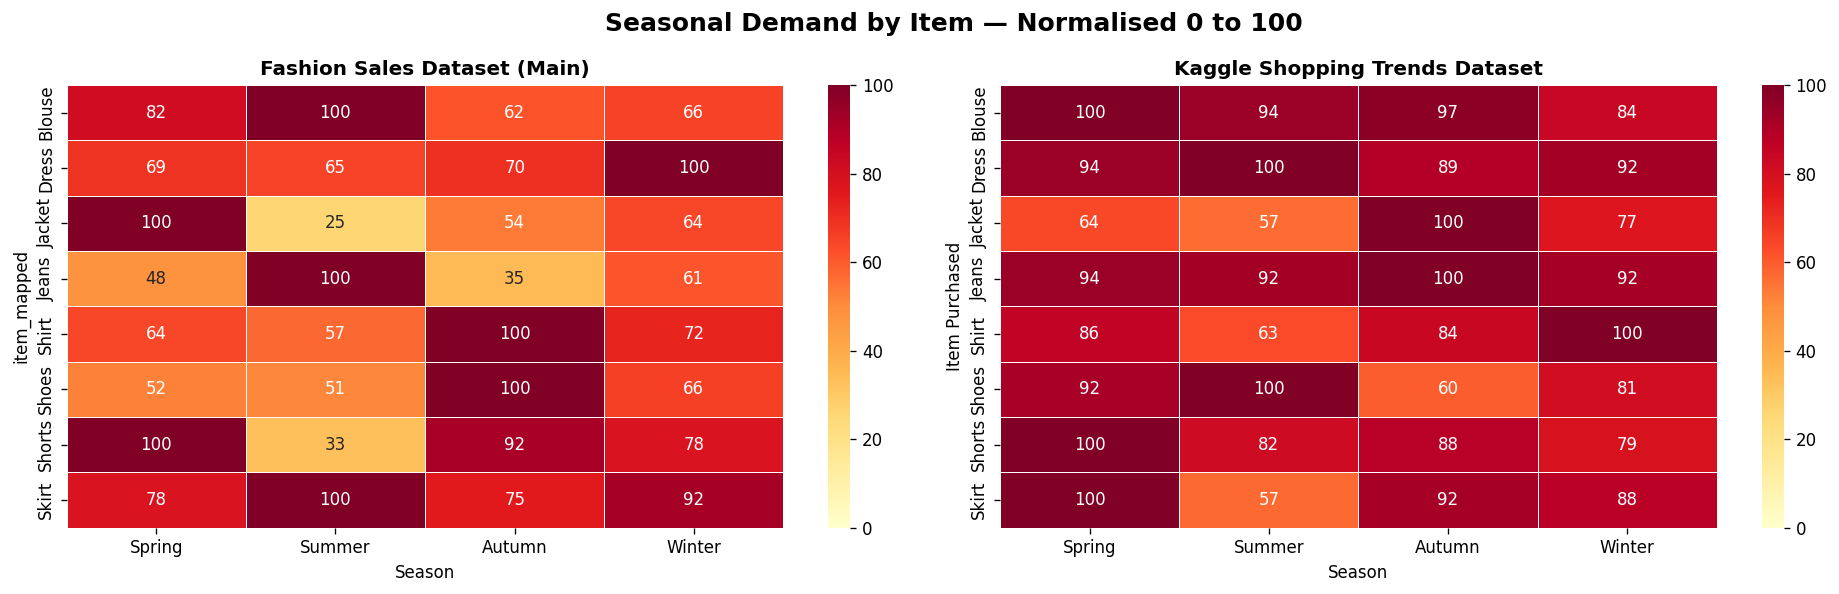

In [3]:
# Aggregate by season × item
main_season   = df_main.groupby(['season', 'item_mapped'])['sales_count'].sum().unstack(fill_value=0).reindex(SEASON_ORDER)
kaggle_season = df_kaggle[df_kaggle['Item Purchased'].isin(SHARED_ITEMS)]\
                  .groupby(['Season', 'Item Purchased'])['Purchase Amount (USD)'].sum()\
                  .unstack(fill_value=0).reindex(SEASON_ORDER)

# Normalise both to 0-100
main_norm   = main_season.div(main_season.max()).mul(100).round(1)
kaggle_norm = kaggle_season.div(kaggle_season.max()).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Seasonal Demand by Item — Normalised 0 to 100', fontsize=15, fontweight='bold')

sns.heatmap(main_norm[SHARED_ITEMS].T, ax=axes[0], cmap='YlOrRd', annot=True,
            fmt='.0f', linewidths=0.5, linecolor='white', vmin=0, vmax=100)
axes[0].set_title('Fashion Sales Dataset (Main)', fontweight='bold')
axes[0].set_xlabel('Season')

kaggle_cols = [c for c in SHARED_ITEMS if c in kaggle_norm.columns]
sns.heatmap(kaggle_norm[kaggle_cols].T, ax=axes[1], cmap='YlOrRd', annot=True,
            fmt='.0f', linewidths=0.5, linecolor='white', vmin=0, vmax=100)
axes[1].set_title('Kaggle Shopping Trends Dataset', fontweight='bold')
axes[1].set_xlabel('Season')

plt.tight_layout()
plt.show()

## 4. Top Item per Season — Do Both Datasets Agree?

In [4]:
print(f'{"Season":10s} {"Main Dataset":22s} {"Kaggle Dataset":22s} {"Match?"}')
print('-' * 65)

matches = 0
for season in SEASON_ORDER:
    main_top   = main_season.loc[season].idxmax()
    if season in kaggle_norm.index:
        kaggle_top = kaggle_norm.loc[season, kaggle_cols].idxmax()
    else:
        kaggle_top = 'N/A'
    match = 'YES' if main_top == kaggle_top else 'NO'
    if match == 'YES': matches += 1
    print(f'{season:10s} {main_top:22s} {kaggle_top:22s} {match}')

print(f'\nAgreement rate: {matches}/{len(SEASON_ORDER)} seasons ({matches/len(SEASON_ORDER)*100:.0f}%)')

Season     Main Dataset           Kaggle Dataset         Match?
-----------------------------------------------------------------
Spring     Jacket                 Blouse                 NO
Summer     Jeans                  Dress                  NO
Autumn     Shirt                  Jacket                 NO
Winter     Shirt                  Shirt                  YES

Agreement rate: 1/4 seasons (25%)


## 5. Gender Preference Comparison

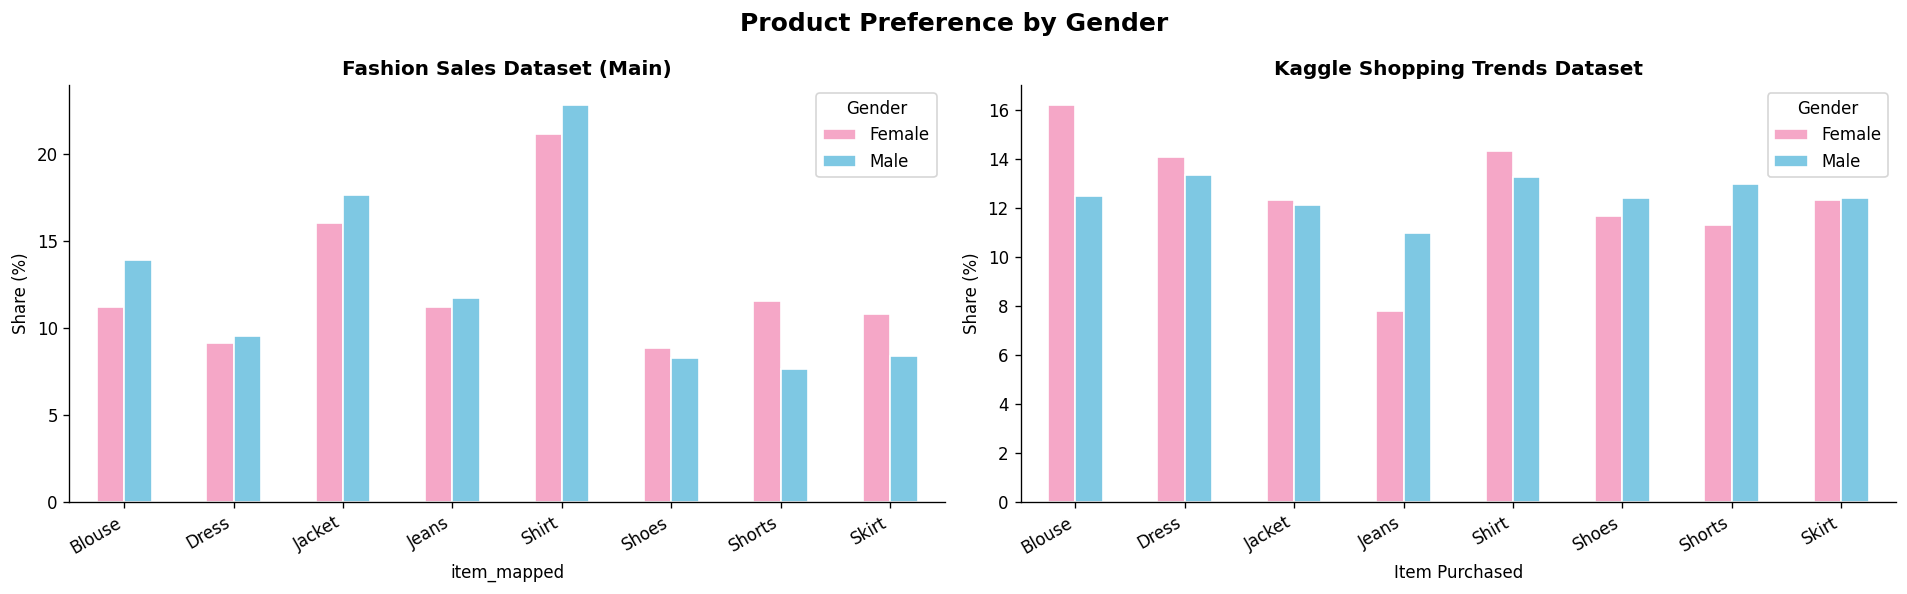

Top item per gender — Main dataset:
  Female: Shirt
  Male: Shirt
Top item per gender — Kaggle dataset:
  Female: Blouse
  Male: Dress


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Product Preference by Gender', fontsize=15, fontweight='bold')

# Main dataset
main_gender = df_main.groupby(['gender', 'item_mapped'])['sales_count'].sum().unstack(fill_value=0)
main_gender_norm = main_gender.div(main_gender.sum(axis=1), axis=0).mul(100)
main_gender_norm[SHARED_ITEMS].T.plot(kind='bar', ax=axes[0],
    color=['#F5A7C7','#7EC8E3'], edgecolor='white')
axes[0].set_title('Fashion Sales Dataset (Main)', fontweight='bold')
axes[0].set_ylabel('Share (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Gender')

# Kaggle dataset
kaggle_gender = df_kaggle[df_kaggle['Item Purchased'].isin(SHARED_ITEMS)]\
                  .groupby(['Gender', 'Item Purchased'])['Purchase Amount (USD)'].sum().unstack(fill_value=0)
kaggle_gender_norm = kaggle_gender.div(kaggle_gender.sum(axis=1), axis=0).mul(100)
kaggle_gender_norm[kaggle_cols].T.plot(kind='bar', ax=axes[1],
    color=['#F5A7C7','#7EC8E3'], edgecolor='white')
axes[1].set_title('Kaggle Shopping Trends Dataset', fontweight='bold')
axes[1].set_ylabel('Share (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

print('Top item per gender — Main dataset:')
for g in ['Female','Male']:
    top = main_gender.loc[g].idxmax()
    print(f'  {g}: {top}')

print('Top item per gender — Kaggle dataset:')
for g in ['Female','Male']:
    top = kaggle_gender[kaggle_cols].loc[g].idxmax()
    print(f'  {g}: {top}')

## 6. Age Group Comparison

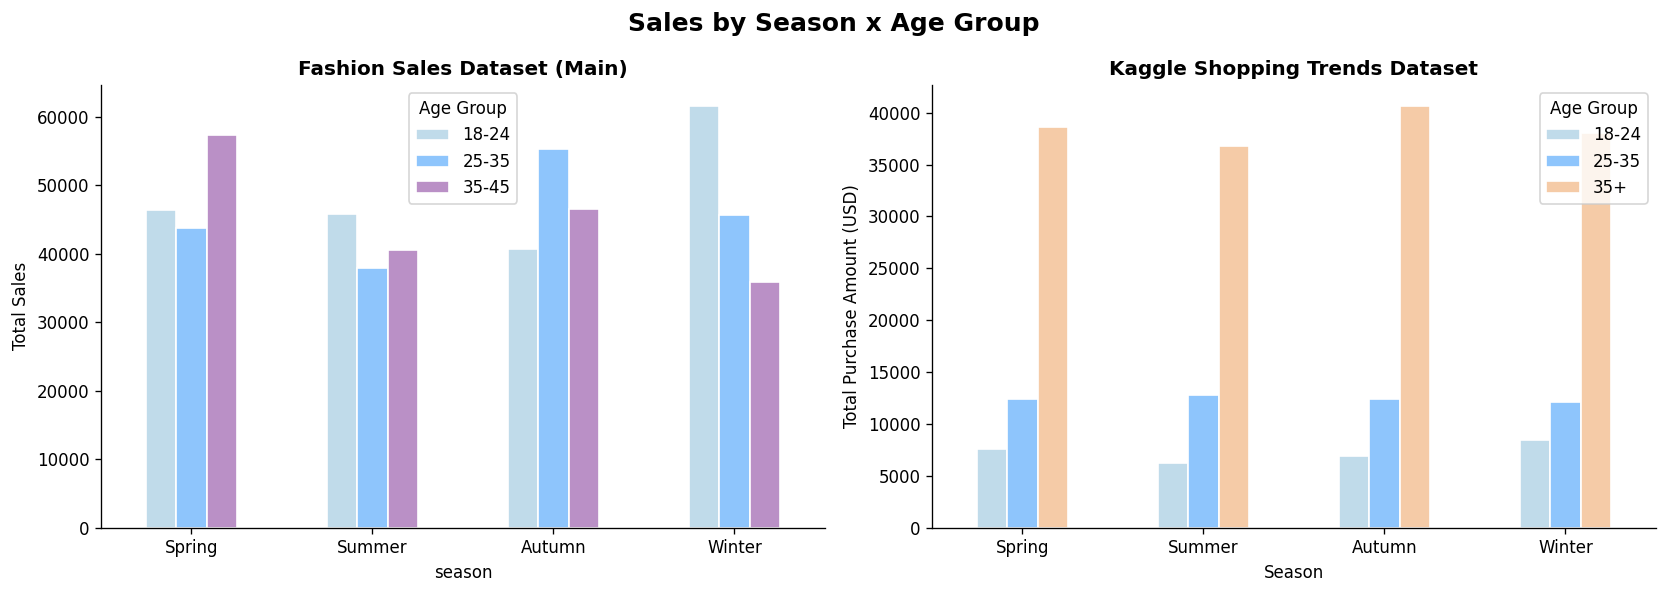

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales by Season x Age Group', fontsize=15, fontweight='bold')

# Main dataset
main_age = df_main.groupby(['season','age_group'])['sales_count'].sum().unstack().reindex(SEASON_ORDER)
main_age.plot(kind='bar', ax=axes[0],
    color=['#C0DBEA','#8EC5FC','#BA90C6'], edgecolor='white')
axes[0].set_title('Fashion Sales Dataset (Main)', fontweight='bold')
axes[0].set_xticklabels(SEASON_ORDER, rotation=0)
axes[0].set_ylabel('Total Sales')
axes[0].legend(title='Age Group')

# Kaggle dataset
kaggle_age = df_kaggle.groupby(['Season','age_group'])['Purchase Amount (USD)'].sum()\
               .unstack().reindex(SEASON_ORDER)
kaggle_age.plot(kind='bar', ax=axes[1],
    color=['#C0DBEA','#8EC5FC','#F5CBA7'], edgecolor='white')
axes[1].set_title('Kaggle Shopping Trends Dataset', fontweight='bold')
axes[1].set_xticklabels(SEASON_ORDER, rotation=0)
axes[1].set_ylabel('Total Purchase Amount (USD)')
axes[1].legend(title='Age Group')

plt.tight_layout()
plt.show()

## 7. Seasonal Correlation — Main vs Kaggle

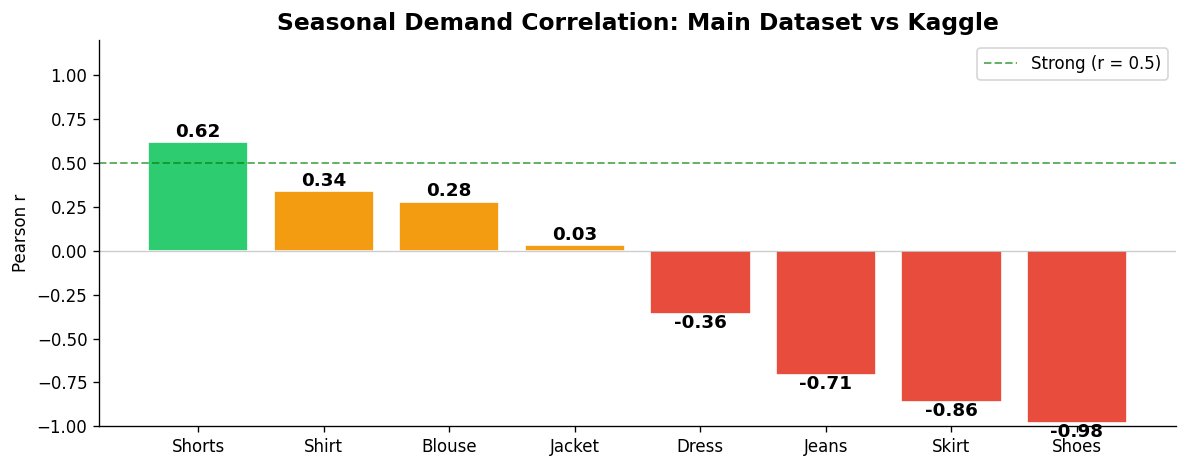

  Item  Pearson r  p-value
Shorts       0.62    0.381
 Shirt       0.34    0.656
Blouse       0.28    0.723
Jacket       0.03    0.970
 Dress      -0.36    0.641
 Jeans      -0.71    0.287
 Skirt      -0.86    0.136
 Shoes      -0.98    0.022


In [7]:
corr_results = []
for item in kaggle_cols:
    if item not in main_norm.columns: continue
    m = main_norm[item].reindex(SEASON_ORDER).values
    k = kaggle_norm[item].reindex(SEASON_ORDER).values
    if np.std(m) < 1e-6 or np.std(k) < 1e-6: continue
    r, p = pearsonr(m, k)
    corr_results.append({'Item': item, 'Pearson r': round(r, 2), 'p-value': round(p, 3)})

corr_df = pd.DataFrame(corr_results).sort_values('Pearson r', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#2ECC71' if r > 0.5 else '#F39C12' if r > 0 else '#E74C3C'
              for r in corr_df['Pearson r']]
bars = ax.bar(corr_df['Item'], corr_df['Pearson r'], color=bar_colors, edgecolor='white')
ax.axhline(0.5, color='green', linestyle='--', linewidth=1.2, alpha=0.6, label='Strong (r = 0.5)')
ax.axhline(0,   color='gray',  linestyle='-',  linewidth=0.8, alpha=0.4)
ax.set_title('Seasonal Demand Correlation: Main Dataset vs Kaggle', fontsize=14, fontweight='bold')
ax.set_ylabel('Pearson r')
ax.set_ylim(-1, 1.2)
ax.legend()
for bar, val in zip(bars, corr_df['Pearson r']):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + 0.03 if val >= 0 else bar.get_height() - 0.08,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(corr_df.to_string(index=False))

## 8. Summary

In [8]:
avg_r = corr_df['Pearson r'].mean()

print('=' * 65)
print('CROSS-DATASET VALIDATION SUMMARY')
print('=' * 65)
print()
print('Datasets compared:')
print('  1. Fashion Sales Dataset  — 2,640 records (2018-2025)')
print('  2. Kaggle Shopping Trends — 3,900 records')
print('     kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset')
print()
print('Product mapping applied (Main -> Kaggle):')
for k, v in PRODUCT_MAP.items():
    print(f'  {k:20s} -> {v}')
print()
print('Seasonal top-item agreement:')
for season in SEASON_ORDER:
    main_top   = main_season.loc[season].idxmax()
    kaggle_top = kaggle_norm.loc[season, kaggle_cols].idxmax() if season in kaggle_norm.index else 'N/A'
    match = 'MATCH' if main_top == kaggle_top else 'DIFFER'
    print(f'  {season:8s}: Main = {main_top:8s} | Kaggle = {kaggle_top:8s} [{match}]')
print()
print(f'Average Pearson r across items: {avg_r:.2f}')
strength = 'Strong alignment' if avg_r > 0.5 else 'Moderate alignment' if avg_r > 0.2 else 'Weak alignment'
print(f'Interpretation: {strength}')
print()
print('Note: Low correlation is expected — Main dataset is from a European/Asian')
print('brand (ZARA), while Kaggle dataset reflects US consumer behaviour.')
print('Regional differences in fashion preferences explain the divergence.')
print('This itself is a meaningful finding worth discussing in the report.')
print('=' * 65)

CROSS-DATASET VALIDATION SUMMARY

Datasets compared:
  1. Fashion Sales Dataset  — 2,640 records (2018-2025)
  2. Kaggle Shopping Trends — 3,900 records
     kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

Product mapping applied (Main -> Kaggle):
  Blouse               -> Blouse
  Casual Jeans         -> Jeans
  Chino Shorts         -> Shorts
  Summer Dress         -> Dress
  Heels                -> Shoes
  Pattern Skirt        -> Skirt
  Biker Jacket         -> Jacket
  Wool Jacket          -> Jacket
  Beach Shirt          -> Shirt
  Business Shirt       -> Shirt

Seasonal top-item agreement:
  Spring  : Main = Jacket   | Kaggle = Blouse   [DIFFER]
  Summer  : Main = Jeans    | Kaggle = Dress    [DIFFER]
  Autumn  : Main = Shirt    | Kaggle = Jacket   [DIFFER]
  Winter  : Main = Shirt    | Kaggle = Shirt    [MATCH]

Average Pearson r across items: -0.20
Interpretation: Weak alignment

Note: Low correlation is expected — Main dataset is from a European/Asian
br